---
# Data Cleaning & Preliminary Analysis

# **EMIF Group Project 1**
#### Clémence Choukroun, Alexis Gavillet, Pierre-Antoine Le Quellec, Aymen Laraoui, Rijad Talovic

## Data Cleaning : Weekly Frequency

Selected Variables
- **WTI** : WTI crude oil futures (CL1 Comdty)
- **HY** : Bloomberg US Corporate High Yield Index (LF98YW Index)
- **SP500** : S&P 500 Index (SPX Index)
- **US2Y** : US Government 2-Year Yield (USGG2YR Index)

## 1. Data Loading

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import statsmodels as sm
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

In [37]:
raw_path = Path("../data/raw/data_hec_projet_1.xlsx")
daily_raw = pd.read_excel(raw_path, sheet_name="Daily", skiprows=5, index_col=0, parse_dates=True)

print("Raw dimensions:", daily_raw.shape)
daily_raw.head()

Raw dimensions: (9443, 13)


,PX_LAST,PX_LAST.1,PX_LAST.2,PX_LAST.3,PX_LAST.4,PX_LAST.5,PX_LAST.6,PX_LAST.7,PX_LAST.8,PX_LAST.9,PX_LAST.10,PX_LAST.11,PX_LAST.12
Dates,,,,,,,,,,,,,
1990-01-01,21.82,19.69,77.8405,NaN,NaN,353.40,567.34,214.69,168.228,7.935,7.841,16.08,401.25
1990-01-02,22.89,19.90,81.0621,NaN,NaN,359.69,568.96,217.30,169.943,7.930,7.875,16.08,399.00
1990-01-03,23.68,20.95,83.0504,NaN,NaN,358.76,569.10,220.45,170.780,7.974,7.927,16.08,395.00
1990-01-04,23.41,20.78,81.1315,NaN,NaN,355.67,571.02,227.30,170.168,7.972,7.910,16.08,396.50
1990-01-05,23.08,20.75,78.7509,NaN,NaN,352.20,566.36,228.91,169.713,7.984,7.885,16.08,405.00


In [38]:
#filtering for selected variables
df_daily = daily_raw.iloc[:, [0, 5, 10, 11]].copy()
df_daily.columns = ["WTI", "SP500", "US2Y", "HY"]

df_daily.head()

,WTI,SP500,US2Y,HY
Dates,,,,
1990-01-01,21.82,353.40,7.841,16.08
1990-01-02,22.89,359.69,7.875,16.08
1990-01-03,23.68,358.76,7.927,16.08
1990-01-04,23.41,355.67,7.910,16.08
1990-01-05,23.08,352.20,7.885,16.08


In [39]:
#identify when HY frequency changes from monthly to higher frequency
hy_changes = df_daily["HY"].dropna()
hy_changes = hy_changes[hy_changes != hy_changes.shift(1)]

gaps = hy_changes.index.to_series().diff().dt.days.dropna()

print(gaps[gaps >= 20].index[-1].date())

1998-07-31


In [40]:
#restrict sample to period with daily HY frequency
df_daily = df_daily.loc["1998-08-01":]

## 2. Weekly resampling of daily data

In [41]:
#resample to weekly frequency (last observation of the week)
df_weekly = df_daily.resample("W-FRI").last()

print(f"Period: {df_weekly.index[0].date()} to {df_weekly.index[-1].date()}")
df_weekly.head()

Period: 1998-08-07 to 2026-03-13


,WTI,SP500,US2Y,HY
Dates,,,,
1998-08-07,14.14,1089.45,5.328,9.03
1998-08-14,13.64,1062.75,5.318,9.31
1998-08-21,13.37,1081.24,5.197,9.56
1998-08-28,13.50,1027.14,4.905,10.01
1998-09-04,14.59,973.89,4.902,10.56


## 3. Returns to Excess Returns

In [42]:
#construct return-based variables for VAR

df_ret = df_weekly.copy()

#log-returns (WTI, SP500)
for col in ["WTI", "SP500"]:
    df_ret[col] = np.log(df_weekly[col] / df_weekly[col].shift(1))

#weekly risk-free rate (decimal)
df_ret["US2Y"] = df_weekly["US2Y"] / (100 * 52)

#VAR 1 variables
ret_wti  = df_ret["WTI"].rename("ret_wti")
er_sp500 = (df_ret["SP500"] - df_ret["US2Y"]).rename("er_sp500")

#change in HY spread (decimal)
spread_hy   = df_weekly["HY"] - df_weekly["US2Y"]
d_spread_hy = ((spread_hy - spread_hy.shift(1)) / 100).rename("d_spread_hy")

## 4. Realized Variance

In [43]:
#construct realized variance series for VAR

#daily log-returns (WTI, SP500)
daily_ret_wti   = np.log(df_daily["WTI"] / df_daily["WTI"].shift(1)).dropna()
daily_ret_sp500 = np.log(df_daily["SP500"] / df_daily["SP500"].shift(1)).dropna()

#daily change in HY spread
daily_spread   = df_daily["HY"] - df_daily["US2Y"]
daily_d_spread = ((daily_spread - daily_spread.shift(1)) / 100).dropna()

#weekly realized variance
rv_wti   = (daily_ret_wti ** 2).resample("W-FRI").sum().rename("rv_wti")
rv_sp500 = (daily_ret_sp500 ** 2).resample("W-FRI").sum().rename("rv_sp500")
rv_hy    = (daily_d_spread ** 2).resample("W-FRI").sum().rename("rv_hy")

Weekly realized variance is computed as the sum of squared daily returns:

$$RV_t = \sum_{d \in \text{week } t} r_d^2$$

where $r_d$ denotes daily log-returns (or daily changes in the HY spread).

In [44]:
#cap extreme values in realized variance (upper tail)

rv_wti   = rv_wti.clip(upper=rv_wti.quantile(0.99))
rv_sp500 = rv_sp500.clip(upper=rv_sp500.quantile(0.99))
rv_hy    = rv_hy.clip(upper=rv_hy.quantile(0.99))

pd.concat([rv_wti, rv_sp500, rv_hy], axis=1).describe().round(6)

,rv_wti,rv_sp500,rv_hy
count,1441.000000,1441.000000,1441.000000
mean,0.002575,0.000654,0.000005
std,0.003219,0.001052,0.000011
min,0.000007,0.000003,0.000000
25%,0.000853,0.000137,0.000001
50%,0.001595,0.000309,0.000002
75%,0.002932,0.000713,0.000004
max,0.019726,0.007425,0.000091


## 5. Final Cleaning & Export

In [45]:
#VAR 1 variables
var1 = pd.concat([ret_wti, er_sp500, d_spread_hy], axis=1).dropna()

#VAR 2 variables: realized variance from daily data
var2 = pd.concat([rv_wti, rv_sp500, rv_hy], axis=1)

#combine datasets
df_final = pd.concat([var1, var2], axis=1, sort=False).dropna()
df_final = df_final.asfreq('W-FRI')

print(f"Period: {df_final.index[0].date()} to {df_final.index[-1].date()}")
print(f"Observations: {len(df_final)}")
df_final.head()

Period: 1998-08-14 to 2026-03-13
Observations: 1440


,ret_wti,er_sp500,d_spread_hy,rv_wti,rv_sp500,rv_hy
Dates,,,,,,
1998-08-14,-0.036001,-0.025836,0.00290,0.004282,0.000611,0.000003
1998-08-21,-0.019993,0.016249,0.00371,0.002764,0.000771,0.000006
1998-08-28,0.009676,-0.052274,0.00742,0.001773,0.001876,0.000022
1998-09-04,0.077647,-0.054178,0.00553,0.006006,0.006555,0.000033
1998-09-11,-0.002058,0.034574,0.00222,0.001817,0.004283,0.000004


           ret_wti     er_sp500  d_spread_hy       rv_wti     rv_sp500        rv_hy
count  1440.000000  1440.000000  1440.000000  1440.000000  1440.000000  1440.000000
mean      0.001246     0.000807    -0.000003     0.002577     0.000654     0.000005
std       0.051711     0.024900     0.003039     0.003220     0.001052     0.000011
min      -0.390397    -0.201152    -0.015265     0.000007     0.000003     0.000000
25%      -0.024628    -0.011246    -0.001304     0.000853     0.000137     0.000001
50%       0.004566     0.002304    -0.000215     0.001596     0.000309     0.000002
75%       0.031516     0.014116     0.001122     0.002932     0.000712     0.000004
max       0.279942     0.114193     0.031480     0.019726     0.007425     0.000091


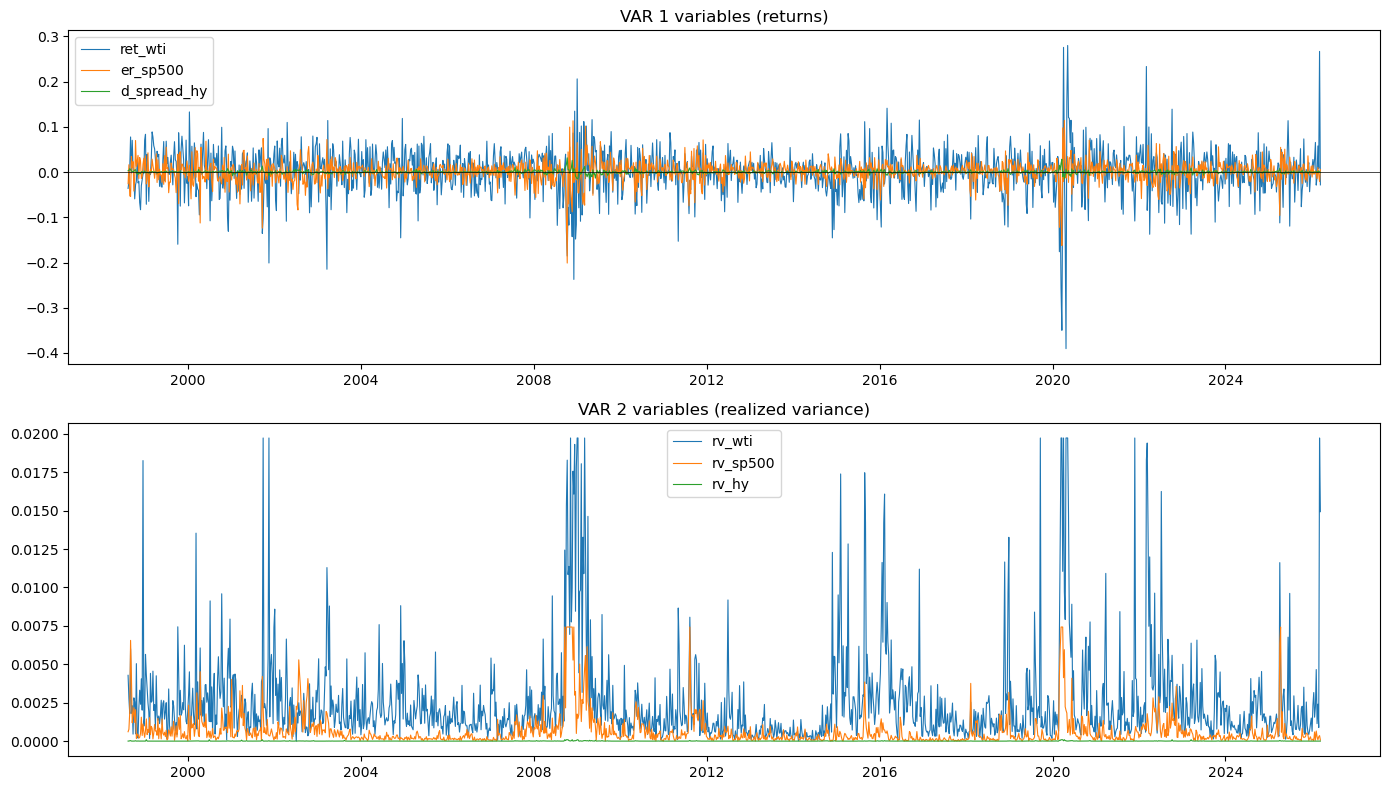

In [46]:
#summary statistics of final dataset
print(df_final.describe().round(6).to_string())

#plot VAR variables
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for col in ["ret_wti", "er_sp500", "d_spread_hy"]:
    axes[0].plot(df_final.index, df_final[col], label=col, linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("VAR 1 variables (returns)")
axes[0].legend()

for col in ["rv_wti", "rv_sp500", "rv_hy"]:
    axes[1].plot(df_final.index, df_final[col], label=col, linewidth=0.8)
axes[1].set_title("VAR 2 variables (realized variance)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [47]:
df_final.to_csv(Path("../data/processed/weekly_cleaned_data.csv"))
print("Exported: ../data/processed/weekly_cleaned_data.csv")

Exported: ../data/processed/weekly_cleaned_data.csv


## 6. Preliminary Statistical Analysis

In [48]:
#summary statistics and normality tests for returns

daily_returns  = pd.concat([daily_ret_wti, daily_ret_sp500, daily_d_spread], axis=1).dropna()
weekly_returns = pd.concat([ret_wti, er_sp500, d_spread_hy], axis=1).dropna()

def moment_table(df):
    return pd.DataFrame({
        "mean": df.mean(),
        "std": df.std(),
        "skewness": df.skew(),
        "kurtosis": df.kurtosis() + 3, 
        "excess_kurtosis": df.kurtosis(),
    })

def jb_pvalues(ret):
    return pd.Series({c: stats.jarque_bera(ret[c].dropna().values).pvalue for c in ret.columns})

mom_daily  = moment_table(daily_returns)
mom_weekly = moment_table(weekly_returns).add_prefix("W_")

compare_moments = pd.concat([
    mom_daily[["skewness", "kurtosis", "excess_kurtosis"]].reset_index(drop=True),
    mom_weekly[["W_skewness", "W_kurtosis", "W_excess_kurtosis"]].reset_index(drop=True)
], axis=1) 
compare_moments.index = ["ret_wti", "er_sp500", "d_spread_hy"]

display(compare_moments)

jb_daily  = jb_pvalues(daily_returns).rename("JB_p_daily")
jb_weekly = jb_pvalues(weekly_returns).rename("JB_p_weekly")

compare_jb = pd.concat([jb_daily.reset_index(drop=True), jb_weekly.reset_index(drop=True)], axis=1).round(4)
compare_jb.index = ["ret_wti", "er_sp500", "d_spread_hy"]

display(compare_jb)

,skewness,kurtosis,excess_kurtosis,W_skewness,W_kurtosis,W_excess_kurtosis
ret_wti,-1.911451,50.736005,47.736005,-0.602216,9.370869,6.370869
er_sp500,-0.348547,13.603476,10.603476,-0.820673,9.637627,6.637627
d_spread_hy,0.540489,97.640223,94.640223,1.956947,23.881764,20.881764


,JB_p_daily,JB_p_weekly
ret_wti,0.0,0.0
er_sp500,0.0,0.0
d_spread_hy,0.0,0.0


In [49]:
#autocorrelation check

lags_to_test = [4, 8, 12] 

#Ljung-Box on weekly returns (EMH)
lb_ret = {}
for col in weekly_returns.columns:
    test = acorr_ljungbox(weekly_returns[col].dropna(), lags=lags_to_test, return_df=True)
    lb_ret[col] = test[["lb_stat", "lb_pvalue"]]

display(pd.concat(lb_ret, axis=0).round(4))

#Ljung-Box on realized variance (volatility clustering)
weekly_variances = pd.concat([rv_wti, rv_sp500, rv_hy], axis=1).dropna()

lb_var = {}
for col in weekly_variances.columns:
    test = acorr_ljungbox(weekly_variances[col].dropna(), lags=lags_to_test, return_df=True)
    lb_var[col] = test[["lb_stat", "lb_pvalue"]]

display(pd.concat(lb_var, axis=0).round(4))

lb_stat  lb_pvalue
ret_wti     4     6.4865     0.1656
            8    18.4865     0.0179
            12   24.0645     0.0199
er_sp500    4    18.0847     0.0012
            8    24.6214     0.0018
            12   29.3075     0.0035
d_spread_hy 4   156.8405     0.0000
            8   167.8667     0.0000
            12  175.8268     0.0000

lb_stat  lb_pvalue
rv_wti   4   1165.8994        0.0
         8   1761.5447        0.0
         12  2010.8053        0.0
rv_sp500 4   2092.4375        0.0
         8   2844.4460        0.0
         12  3205.9712        0.0
rv_hy    4    766.2628        0.0
         8   1004.9867        0.0
         12  1222.4130        0.0

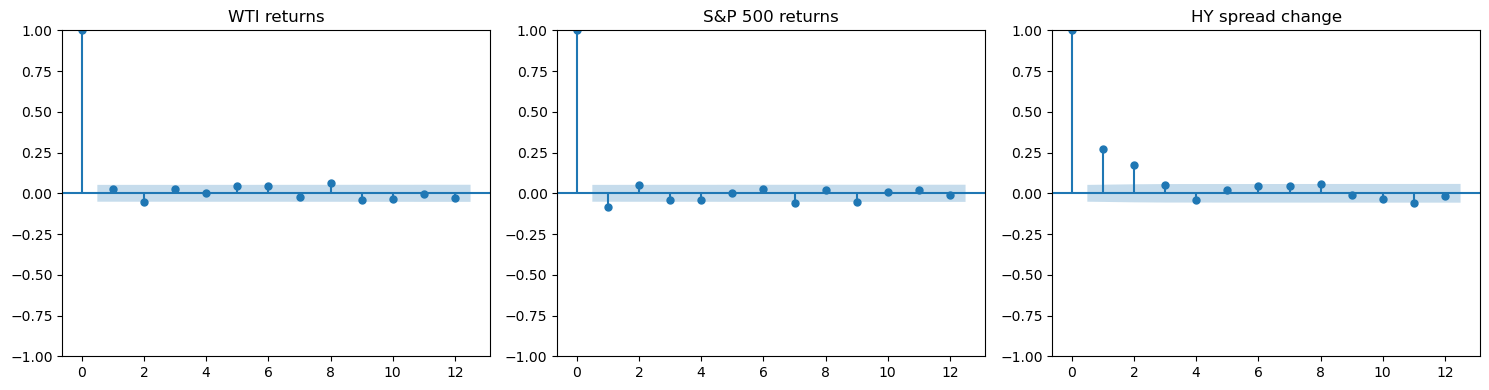

In [50]:
#visual inspection of autocorrelation (returns)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_acf(ret_wti.dropna(), lags=12, ax=axes[0], title="WTI returns")
plot_acf(er_sp500.dropna(), lags=12, ax=axes[1], title="S&P 500 returns")
plot_acf(d_spread_hy.dropna(), lags=12, ax=axes[2], title="HY spread change")

plt.tight_layout()
plt.show()

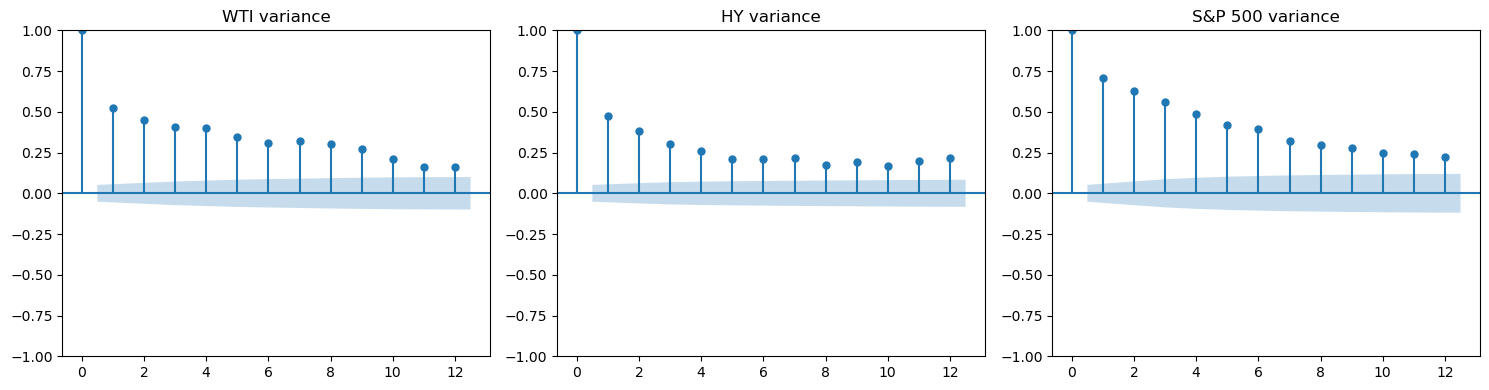

In [51]:
#visual inspection of autocorrelation (realized variance)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_acf(rv_wti.dropna(), lags=12, ax=axes[0], title="WTI variance")
plot_acf(rv_hy.dropna(), lags=12, ax=axes[1], title="HY variance")
plot_acf(rv_sp500.dropna(), lags=12, ax=axes[2], title="S&P 500 variance")

plt.tight_layout()
plt.show()

---
# VAR Models

## Testing for Stationarity

In [52]:
#ADF test for stationarity

variables = df_final.columns.tolist()
for i in variables:
    result = sm.tsa.stattools.adfuller(df_final[i])
    print(f"{i:<12}: ADF = {result[0]:8.4f}, nb of lags used {result[2]:>2}, p-value = {result[1]:.6f}")

ret_wti     : ADF = -11.8303, nb of lags used  8, p-value = 0.000000
er_sp500    : ADF = -20.5501, nb of lags used  3, p-value = 0.000000
d_spread_hy : ADF =  -7.9360, nb of lags used 22, p-value = 0.000000
rv_wti      : ADF =  -7.4003, nb of lags used 10, p-value = 0.000000
rv_sp500    : ADF =  -8.5132, nb of lags used  6, p-value = 0.000000
rv_hy       : ADF =  -6.3951, nb of lags used 11, p-value = 0.000000


## Number of lags selection

In [53]:
#lag selection for VAR 1 (returns)

var1_data = df_final[["ret_wti", "d_spread_hy", "er_sp500"]]
model1 = VAR(var1_data)
results1 = model1.select_order(maxlags=20)
print(results1.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -25.49      -25.48   8.527e-12      -25.48
1       -25.64     -25.59*   7.330e-12      -25.62
2       -25.66      -25.58   7.198e-12     -25.63*
3       -25.66      -25.55   7.197e-12      -25.62
4       -25.66      -25.52   7.149e-12      -25.61
5       -25.67      -25.49   7.103e-12      -25.60
6       -25.67      -25.46   7.108e-12      -25.59
7       -25.68      -25.43   7.064e-12      -25.58
8       -25.68      -25.40   7.032e-12      -25.58
9       -25.68      -25.37   7.030e-12      -25.56
10      -25.68      -25.33   7.058e-12      -25.55
11     -25.68*      -25.30  7.020e-12*      -25.54
12      -25.68      -25.27   7.062e-12      -25.52
13      -25.67      -25.23   7.073e-12      -25.51
14      -25.67      -25.20   7.086e-12      -25.49
15      -25.67      -25.16   7.134e-12      -25.48
16      -25.66      -25.11   7.

In [54]:
#lag selection for VAR 2 (realized variances)

var2_data = df_final[["rv_wti", "rv_hy", "rv_sp500"]]
model2 = VAR(var2_data)
results2 = model2.select_order(maxlags=20)
print(results2.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -48.79      -48.78   6.437e-22      -48.79
1       -49.78      -49.74   2.404e-22      -49.76
2       -49.89     -49.81*   2.152e-22      -49.86
3       -49.91      -49.79   2.120e-22      -49.86
4       -49.92      -49.78   2.085e-22     -49.87*
5       -49.92      -49.74   2.088e-22      -49.85
6       -49.92      -49.71   2.085e-22      -49.84
7       -49.93      -49.68   2.072e-22      -49.84
8       -49.93      -49.65   2.075e-22      -49.82
9       -49.92      -49.61   2.082e-22      -49.81
10      -49.93      -49.58   2.077e-22      -49.80
11      -49.93      -49.55   2.075e-22      -49.79
12      -49.93      -49.52   2.065e-22      -49.78
13     -49.93*      -49.49  2.060e-22*      -49.77
14      -49.93      -49.45   2.070e-22      -49.75
15      -49.93      -49.42   2.071e-22      -49.74
16      -49.92      -49.38   2.

## VAR 1 — Returns

In [55]:
#estimate VAR(2) for returns

var1_fitted = model1.fit(2)
print(var1_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 04, Apr, 2026
Time:                     22:14:04
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -25.5605
Nobs:                     1438.00    HQIC:                  -25.6087
Log likelihood:           12333.1    FPE:                7.34145e-12
AIC:                     -25.6375    Det(Omega_mle):     7.23527e-12
--------------------------------------------------------------------
Results for equation ret_wti
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.001519         0.001356            1.120           0.263
L1.ret_wti            -0.003263         0.027648           -0.118           0.906
L1.d_spread_hy        -2.661819         0.613157      

## VAR 2 — Realized Variances

In [56]:
#estimate VAR(4) for realized variances

var2_fitted = model2.fit(4)
print(var2_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 04, Apr, 2026
Time:                     22:14:04
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -49.7474
Nobs:                     1436.00    HQIC:                  -49.8371
Log likelihood:           29747.6    FPE:                2.15185e-22
AIC:                     -49.8905    Det(Omega_mle):     2.09445e-22
--------------------------------------------------------------------
Results for equation rv_wti
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.000610         0.000097            6.298           0.000
L1.rv_wti           0.270146         0.027358            9.875           0.000
L1.rv_hy           36.369729         7.895391            4.606     

## Granger Causality Tests

In [57]:
def granger_table(fitted, pairs):
    rows = []
    for causing, caused in pairs:
        res = fitted.test_causality(caused=caused, causing=causing)
        rows.append({
            "Causing variable": causing,
            "Caused variable": caused,
            "Test statistic": round(res.test_statistic, 4),
            "p-value": round(res.pvalue, 4),
            "Significant at 5%": "Yes" if res.pvalue < 0.05 else "No",
        })
    return pd.DataFrame(rows)

pairs_var1 = [
    ("ret_wti", "er_sp500"),
    ("ret_wti", "d_spread_hy"),
    ("er_sp500", "ret_wti"),
    ("er_sp500", "d_spread_hy"),
    ("d_spread_hy", "ret_wti"),
    ("d_spread_hy", "er_sp500"),
]

pairs_var2 = [
    ("rv_wti", "rv_sp500"),
    ("rv_wti", "rv_hy"),
    ("rv_sp500", "rv_wti"),
    ("rv_sp500", "rv_hy"),
    ("rv_hy", "rv_wti"),
    ("rv_hy", "rv_sp500"),
]

print("Granger Causality: VAR 1 (returns)")
display(granger_table(var1_fitted, pairs_var1))

print("\nGranger Causality: VAR 2 (realized variances)")
display(granger_table(var2_fitted, pairs_var2))

Granger Causality: VAR 1 (returns)


,Causing variable,Caused variable,Test statistic,p-value,Significant at 5%
0,ret_wti,er_sp500,1.3625,0.2561,No
1,ret_wti,d_spread_hy,1.7520,0.1735,No
2,er_sp500,ret_wti,1.9653,0.1402,No
3,er_sp500,d_spread_hy,4.1346,0.0161,Yes
4,d_spread_hy,ret_wti,11.5768,0.0000,Yes
5,d_spread_hy,er_sp500,0.9272,0.3957,No



Granger Causality: VAR 2 (realized variances)


,Causing variable,Caused variable,Test statistic,p-value,Significant at 5%
0,rv_wti,rv_sp500,2.2974,0.0567,No
1,rv_wti,rv_hy,7.8036,0.0000,Yes
2,rv_sp500,rv_wti,5.7388,0.0001,Yes
3,rv_sp500,rv_hy,12.0214,0.0000,Yes
4,rv_hy,rv_wti,7.0133,0.0000,Yes
5,rv_hy,rv_sp500,5.4570,0.0002,Yes


## Impulse Response Functions

VAR 1 : t=0 Impulse vector (from WTI return shock):    [ 0.051284 -0.000842  0.006236]
VAR 2 : t=0 Impulse vector (from WTI variance shock): [2.527e-03 2.000e-06 1.570e-04]


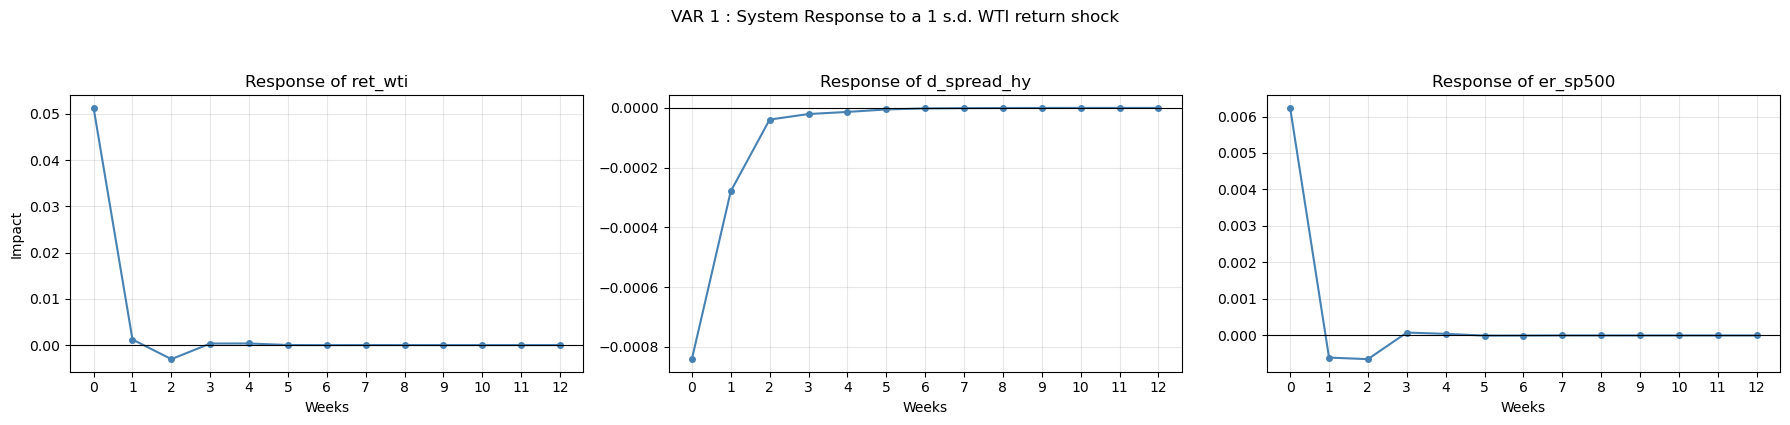

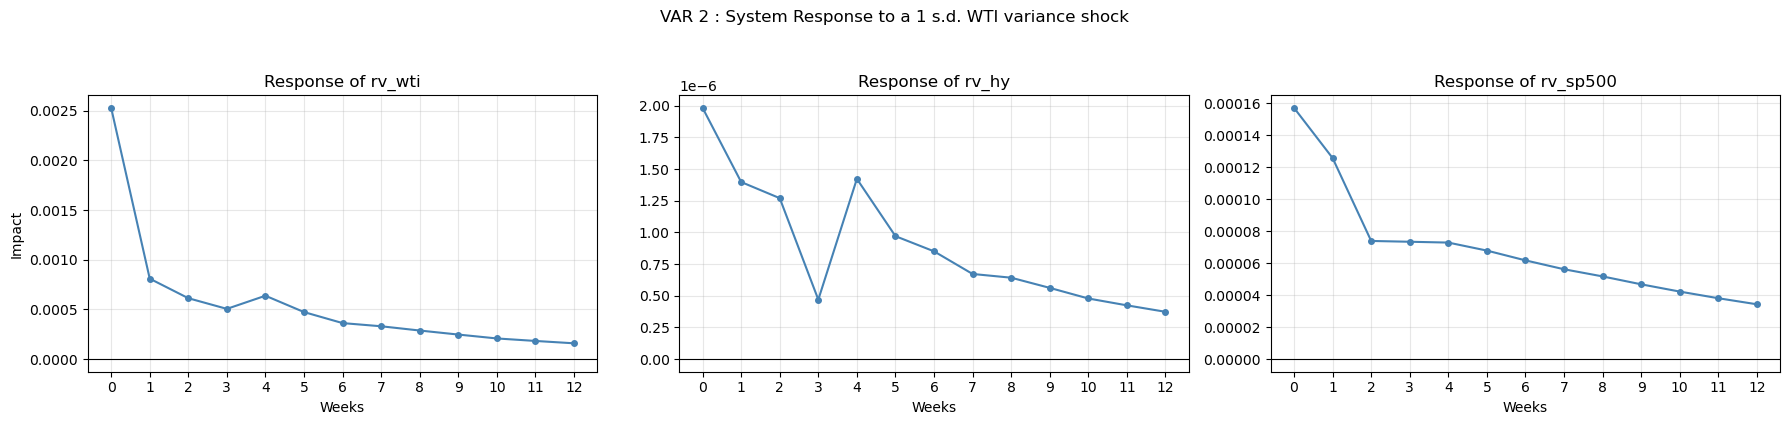

In [58]:
#impulse responses with Cholesky ordering: WTI, HY, SP500
variables_var1 = ["ret_wti", "d_spread_hy", "er_sp500"]
variables_var2 = ["rv_wti", "rv_hy", "rv_sp500"]

irf_var1_fitted = VAR(df_final[variables_var1]).fit(2)
irf_var2_fitted = VAR(df_final[variables_var2]).fit(4)

def compute_irfs_shock(lag_matrices, cholesky_P, shock_vector, n_periods): 
    n_lags = len(lag_matrices) 
    n_vars = lag_matrices.shape[1] 
    
    responses = np.zeros((n_periods + 1, n_vars)) 
    responses[0] = cholesky_P @ shock_vector 
    
    for period in range(1, n_periods + 1): 
        for lag in range(1, min(period, n_lags) + 1): 
            responses[period] += lag_matrices[lag-1] @ responses[period - lag] 
            
    return responses

oil_shock_vector = np.array([1, 0, 0])

# VAR 1 (returns)
P1 = np.linalg.cholesky(irf_var1_fitted.sigma_u)
manual1_shock_matrix = compute_irfs_shock(irf_var1_fitted.coefs, P1, oil_shock_vector, 12)
print(f"VAR 1 : t=0 Impulse vector (from WTI return shock):    {np.round(manual1_shock_matrix[0], 6)}")

# VAR 2 (realized variances)
P2 = np.linalg.cholesky(irf_var2_fitted.sigma_u)
manual2_shock_matrix = compute_irfs_shock(irf_var2_fitted.coefs, P2, oil_shock_vector, 12)
print(f"VAR 2 : t=0 Impulse vector (from WTI variance shock): {np.round(manual2_shock_matrix[0], 6)}")

# VAR 1 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, (ax, title) in enumerate(zip(axes, variables_var1)):
    ax.plot(manual1_shock_matrix[:, i], color="steelblue", marker='o', markersize=4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(13))
    ax.set_title(f"Response of {title}")
    ax.set_xlabel("Weeks")
    if i == 0:
        ax.set_ylabel("Impact")
fig.suptitle("VAR 1 : System Response to a 1 s.d. WTI return shock", y=1.05)
plt.tight_layout()
plots_dir = Path("../plots")
fig.savefig(plots_dir/ "irf_var1.png", dpi=300, bbox_inches="tight")
plt.show()

# VAR 2 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, (ax, title) in enumerate(zip(axes, variables_var2)):
    ax.plot(manual2_shock_matrix[:, i], color="steelblue", marker='o', markersize=4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(13))
    ax.set_title(f"Response of {title}")
    ax.set_xlabel("Weeks")
    if i == 0:
        ax.set_ylabel("Impact")
fig.suptitle("VAR 2 : System Response to a 1 s.d. WTI variance shock", y=1.05)
plt.tight_layout()
fig.savefig(plots_dir/ "irf_var2.png", dpi=300, bbox_inches="tight")
plt.show()